<table style="width:100%">
  <tr>
    <td valign="top"><img src="../data/img/FER_logo_2.png" width=300 height=80 align="left"></td>
    <td valign="top"><img src="../data/img/LARES_2_transparent.png" width=250 height=80 align="right"></td>
  </tr>
 </table>

# Wheat - Clustering

In [1]:
# Importing Modules
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "serif",
    # Use 26pt font in plots
    "axes.labelsize": 16,
    "font.size": 16,
    "figure.titlesize": 16,
    # Make the legend/label fonts a little smaller
    "legend.title_fontsize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
}

plt.rcParams.update(tex_fonts)
sns.set(style="whitegrid", color_codes=True)
%matplotlib inline
# %matplotlib notebook
%config InlineBackend.figure_format='svg'
plt.rcParams['figure.figsize'] = (10, 7)

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Auxiliary functions

In [4]:
def plot_pca_component(pca_features, component_num):
    first_comp = pca_features[:, component_num]
    comps = pd.DataFrame(list(zip(first_comp, X_scaled.columns)), columns=["weights", "features"])
    comps["abs_weights"] = comps["weights"].apply(lambda x: np.abs(x))
    ax = sns.barplot(data=comps.sort_values("abs_weights", ascending=False).head(10), 
                     x="weights",y="features",palette="Blues_d")
    ax.set_title("PCA Component Makeup: #" + str(component_num))
    plt.show()

In [5]:
def elbow_method(X_train, n):
    wcss = []
    # calculate Within Cluster Sum of Squares (WCSS) for KMeans with 1-n clusters
    for i in range(1, n):
        kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
        kmeans.fit(X_train)
        wcss.append(kmeans.inertia_)
    
    fig = plt.figure(figsize = (10, 10))
    
    plt.plot(range(1, n), wcss)
    plt.title('The Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.show()

## The data

![wheat](../data/img/wheat.jpg)

The data consists of seven geometric parameters of wheat kernels were measured:
1. area A,
2. perimeter P,
3. compactness C = 4*pi*A/P^2,
4. length of kernel,
5. width of kernel,
6. asymmetry coefficient
7. length of kernel groove.

All of these parameters were real-valued continuous.

## Unsupervised learning
0. Preprocess data

1. Create/build model

2. Fit/Evaluate model

3. Hands on

## 0. (Pre)process data

In [6]:
seeds_df = pd.read_csv("../data/wheat/seeds_dataset.txt", sep="\t", header=None)

In [7]:
seeds_df

,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


In [8]:
seeds_df.rename(columns={0: 'area', 1: 'perimeter', 2: 'compactness', 3: 'kernel_length', 
                         4: 'kernel_width', 5: 'asymmetry', 6: 'groove_lenght', 7: 'grain_type'}, inplace=True)

In [9]:
seeds_df

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_lenght,grain_type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


### Correlation

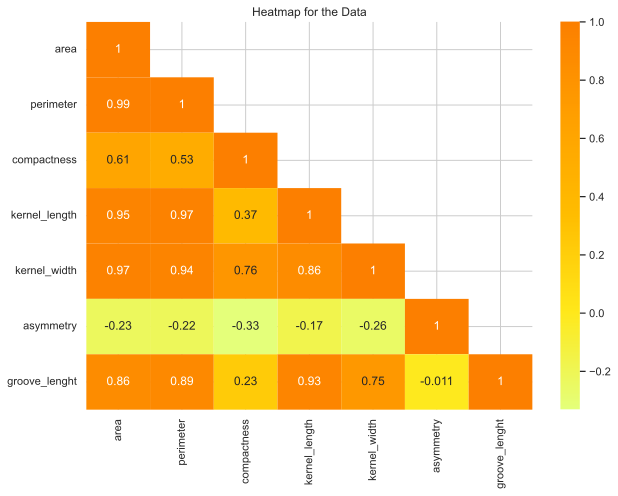

In [10]:
seeds_corr = seeds_df.iloc[:, :-1].corr()

mask = np.zeros_like(seeds_corr, dtype=bool)
mask[np.tril_indices_from(mask)] = True

sns.heatmap(seeds_corr, mask=~mask, cmap = 'Wistia', annot = True)
plt.title('Heatmap for the Data')
plt.show();

### Separate input features and corresponding outputs

In [11]:
y = seeds_df['grain_type']
X = seeds_df.drop('grain_type', axis=1)

### Scaling

In [12]:
scaler = MinMaxScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X))
X_scaled.columns = X.columns
X_scaled.index = seeds_df.index

In [13]:
X_scaled.describe()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_lenght
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,0.402032,0.444067,0.570767,0.410773,0.448043,0.381633,0.437751
std,0.274759,0.269826,0.214423,0.249473,0.269219,0.195498,0.241989
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.158640,0.214876,0.442831,0.204533,0.223806,0.233575,0.258986
50%,0.355524,0.394628,0.593013,0.351633,0.432644,0.368474,0.346627
75%,0.634089,0.682851,0.723004,0.608530,0.664113,0.520570,0.668636
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
# save the scaler to disk
filename = '../models/scaler_clustering_wheat.pkl'
pickle.dump(scaler, open(filename, 'wb'))
 
# load the scaler from disk
# scaler = pickle.load(open(filename, 'rb'))

## PCA

In [15]:
# Create a PCA instance: pca
pca = PCA()

### Apply the fit_transform method of the pca model

In [16]:
X_scaled.columns

Index(['area', 'perimeter', 'compactness', 'kernel_length', 'kernel_width',
       'asymmetry', 'groove_lenght'],
      dtype='object')

In [17]:
pca_features = pca.fit_transform(X_scaled)

### Plot variance for PCA components

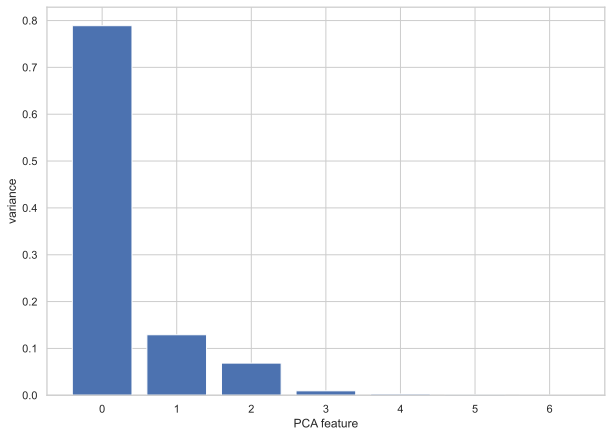

In [18]:
# Plot the explained variances
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_ratio_)
plt.xlabel('PCA feature')
plt.ylabel('variance')
plt.xticks(features)
plt.show()

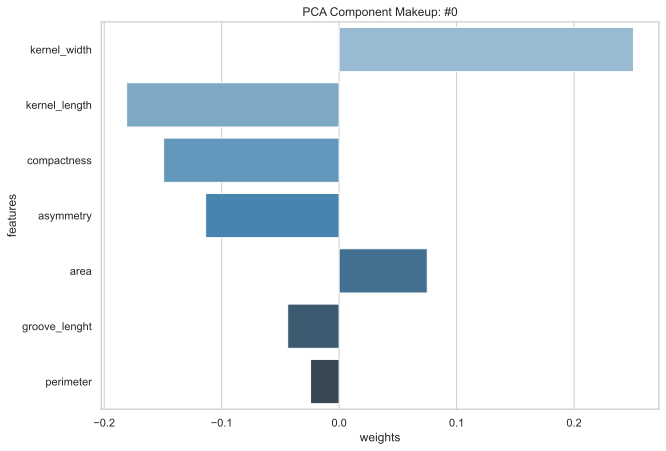

In [19]:
plot_pca_component(pca_features=pca_features, component_num=0)

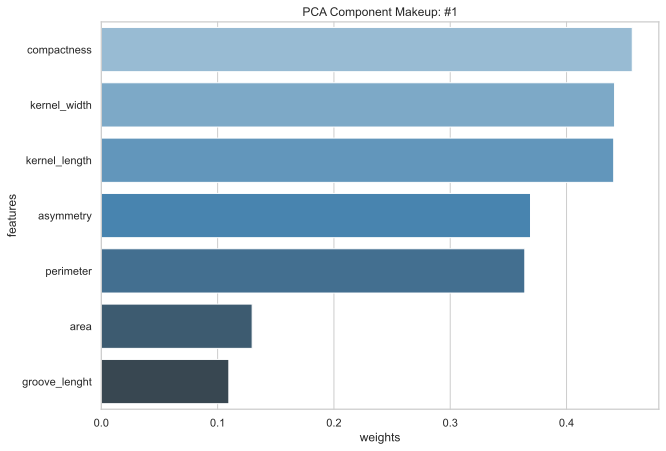

In [20]:
plot_pca_component(pca_features=pca_features, component_num=1)

### K-means

## 1. Create/Build model

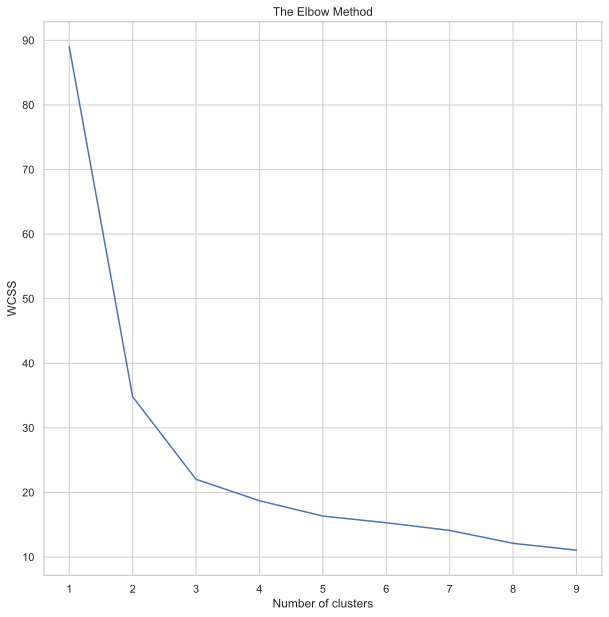

In [21]:
elbow_method(pca_features, 10)

In [22]:
model_kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)

## 2. Fit/Evaluate model

In [23]:
y_kmeans = model_kmeans.fit_predict(pca_features)

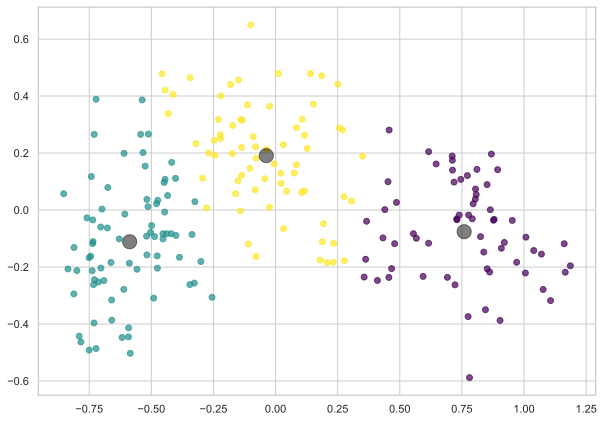

In [24]:
# Assign the columns of new_points: xs and ys
xs = pca_features[:,0]
ys = pca_features[:,1]
# Make a scatter plot of xs and ys, using labels to define the colors
plt.scatter(xs,ys,alpha=0.7, c=y_kmeans, cmap='viridis')
# Assign the cluster centers: centroids
centroids = model_kmeans.cluster_centers_
# Assign the columns of centroids: centroids_x, centroids_y
centroids_x = centroids[:,0]
centroids_y = centroids[:,1]
# Make a scatter plot of centroids_x and centroids_y
plt.scatter(centroids_x,centroids_y,c='black', s=200, alpha=0.5)
plt.show()

In [25]:
# Create crosstab: ct
ct = pd.crosstab(y,y_kmeans+1)
ct

col_0,1,2,3
grain_type,,,
1,2,10,58
2,61,0,9
3,0,67,3


In [26]:
# If you're satisfied with the model, save it to disk
filename = '../models/kmeans_wheat.pkl'
pickle.dump(model_kmeans, open(filename, 'wb'))
 
# load the model from disk
# model_kmeans = pickle.load(open(filename, 'rb'))
# result = model_kmeans.predict(X_test)

## Hierarchical clustering

In [27]:
"""
Perform hierarchical clustering on samples using the
linkage() function with the method='complete' keyword argument.
Assign the result to mergings.
"""
# mergings = linkage(X.values, method='complete')
mergings = linkage(X.values, method='ward')

In [28]:
# mergings

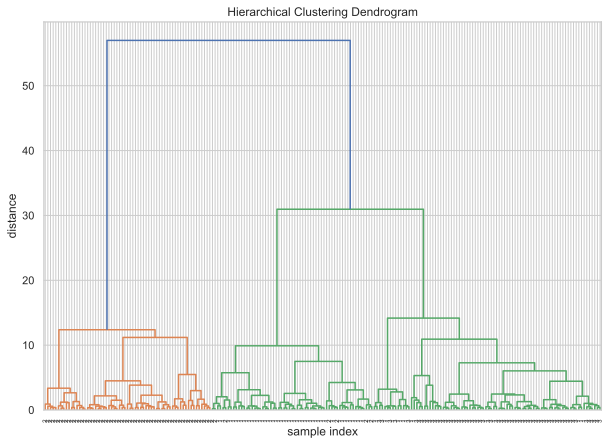

In [29]:
"""
Plot a dendrogram using the dendrogram() function on mergings,
specifying the keyword arguments labels=varieties, leaf_rotation=90,
and leaf_font_size=6.
"""
fig, ax = plt.subplots()

dendrogram(mergings,
           labels=y.values,
           ax=ax,
           leaf_rotation=90,
           leaf_font_size=6,
           )

ax.set_title('Hierarchical Clustering Dendrogram')
ax.set_xlabel('sample index')
ax.set_ylabel('distance')

plt.show()

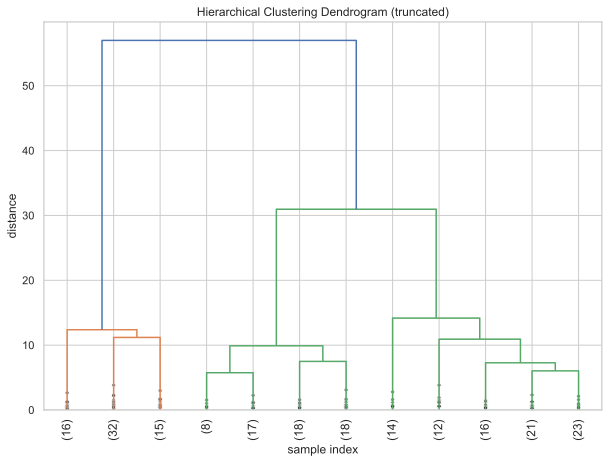

In [30]:
fig, ax = plt.subplots()

dendrogram(
    mergings,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=12,  # show only the last p merged clusters
    show_leaf_counts=True,  # otherwise numbers in brackets are counts
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)

ax.set_title('Hierarchical Clustering Dendrogram (truncated)')
ax.set_xlabel('sample index')
ax.set_ylabel('distance')

plt.show()



_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 3b_Clustering_Wheat_  
_Instructors: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_  
_Intended user: XY_  
_Date: 1st January 1991_  

_References:_
- _Seeds dataset (UCI ML): https://archive.ics.uci.edu/dataset/236/seeds_
- _Scikit-learn Clustering: https: //scikit-learn.org/1.5/modules/clustering.html_
- _Scikit-learn KMeans clustering: https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans_
- _SciPy Hierarchical clustering: https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html_
- _Scikit-learn PCA: https://scikit-learn.org/1.5/modules/generated/sklearn.decomposition.PCA.html_

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_

